### 1) Setup & imports

In [12]:
# === setup & imports ===
import os, torch, ast, random
import numpy as np
import matplotlib.pyplot as plt

from config import *
from models.gaussian_forward import GaussianForwardModel
from utils.data_utils.load_data import load_dataset  # returns (P, S, C_tensor)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### 2) Load stats (for normalization/denormalization)

In [13]:
# === load normalization stats ===
S_mean = torch.tensor(np.load(f"data/S_mean.npy"), dtype=torch.float32, device=device)
S_std  = torch.tensor(np.load(f"data/S_std.npy"),  dtype=torch.float32, device=device)
P_mean = torch.tensor(np.load(f"data/P_mean.npy"), dtype=torch.float32, device=device)
P_std  = torch.tensor(np.load(f"data/P_std.npy"),  dtype=torch.float32, device=device)

def norm_S(S): return (S - S_mean) / S_std
def denorm_P(Pn): return Pn * P_std + P_mean  

print("✅ Loaded S & P normalization stats")

✅ Loaded S & P normalization stats


### 3) Load model checkpoint

In [14]:
# === specify trial to load ===
trial = 5
save_dir = f"checkpoints/gaussian/gaussian_trial_{trial}"
ckpt_path = f"{save_dir}/gaussian_ckpt_{trial}.pt"
config_path = f"{save_dir}/config_{trial}.txt"

# === load config file into a dict ===
config_dict = {}
with open(config_path, "r") as f:
    for line in f:
        if ":" in line:
            key, val = line.strip().split(":", 1)
            key, val = key.strip(), val.strip()
            try:
                config_dict[key] = ast.literal_eval(val)
            except Exception:
                config_dict[key] = val

print("✅ Loaded config:", config_dict)

# === rebuild model using config values ===
S_DIM = config_dict.get("S_DIM", 4)
P_DIM = config_dict.get("P_DIM", 9)
HIDDEN_DIMS = config_dict.get("HIDDEN_DIMS", [128, 64, 32])

model = GaussianForwardModel(S_DIM, P_DIM, hidden_dims=HIDDEN_DIMS).to(device)
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()

print(f"✅ Loaded Gaussian Forward Model from trial {trial}:\n{model}")

✅ Loaded config: {'S_DIM': 4, 'P_DIM': 9, 'HIDDEN_DIMS': [128, 64, 32], 'BATCH_SIZE': 32, 'LEARNING_RATE': 0.001, 'NUM_EPOCHS': 400, 'BETA_VAR_REG': 0.8, 'SIGMA_MIN': 0.001}
✅ Loaded Gaussian Forward Model from trial 5:
GaussianForwardModel(
  (backbone): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): Tanh()
  )
  (mu): Linear(in_features=32, out_features=9, bias=True)
  (log_sigma): Linear(in_features=32, out_features=9, bias=True)
)


/var/folders/9z/9fdpt4_148s8zzl9h0tr9dgw0000gn/T/ipykernel_61465/1882498164.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, 

### 4) Load the distributional dataset and group by S

In [15]:
# === load empirical distributional dataset and group by S ===
DISTRIBUTIONAL_DATA_PATH = "data/dataset_distributional_2.csv"
P_all, S_all, _ = load_dataset(DISTRIBUTIONAL_DATA_PATH)

S_np = np.round(S_all.numpy(), 6)
P_np = P_all.numpy()

keys, inverse = np.unique(S_np, axis=0, return_inverse=True)
empirical_data = { tuple(k.tolist()): P_np[inverse == i] for i, k in enumerate(keys) }

S_keys = list(empirical_data.keys())
print(f"✅ Grouped {len(S_keys)} unique S values from distributional dataset.")

✅ Grouped 30 unique S values from distributional dataset.


### trying different rho-scaling functions (optional)

In [16]:
from utils.rho_scaling import *
EPS_SIG = 1e-8      # floor to keep NLL well-defined

# choose one:
# g_rho = lambda rho: g_targeted(rho, mode="power", rho_thresh=0.90, floor=0.0, k=1.0)
# g_rho = lambda rho: g_targeted(rho, mode="linear", rho_thresh=0.95, floor=0.20)
# g_rho = lambda r: g_targeted_tail(r, rho_thresh=0.92, knee=0.98, k1=1.2, k2=2.0, floor=0.05)
# g_rho = lambda r: g_targeted_tail(r, rho_thresh=0.92, knee=0.98, k1=1.2, k2=3.0, floor=0.08)
# g_rho = lambda r: g_tail_strict(r, rho_thresh=0.92, knee=0.97, k1=1.0, k2=3.0, floor=0.07)
# g_rho = lambda rho: g_targeted(rho, mode="power", rho_thresh=0.92, floor=EPS_SIG, k=1.8)
g_rho = g_none

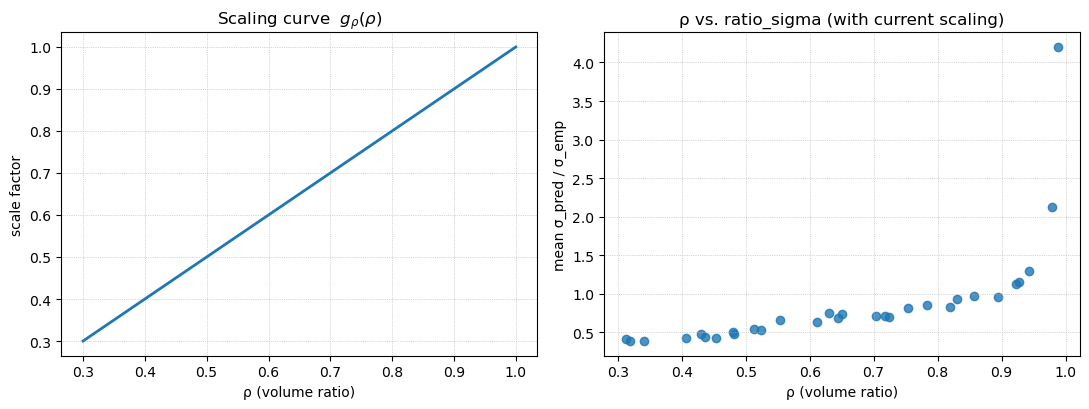

Top-ρ cases:
  ρ=0.9888  ratio_sigma=4.20
  ρ=0.9782  ratio_sigma=2.13
  ρ=0.9437  ratio_sigma=1.30
  ρ=0.9266  ratio_sigma=1.15
  ρ=0.9220  ratio_sigma=1.12


In [17]:
# === visualize g_rho(ρ) and empirical ratio_sigma vs ρ (with current g_rho) ===
import numpy as np
import matplotlib.pyplot as plt

# 1) plot g_rho over a dense rho grid
rho_grid = np.linspace(0.30, 1.0, 300)
scale_grid = np.array([g_rho(r) for r in rho_grid])

# 2) compute (rho, ratio_sigma) for a subset of S (same selection style as before)
num_to_eval = min(200, len(S_keys))
sel_indices = np.linspace(0, len(S_keys)-1, num_to_eval, dtype=int)

rhos, ratios = [], []
for sidx in sel_indices:
    S_arr = np.array(S_keys[sidx], float)
    emp   = empirical_data[S_keys[sidx]]  # (n_emp, P_DIM)
    if emp.size == 0: 
        continue

    # predict mu, sigma (raw space)
    Sv = torch.tensor(S_arr, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        mu_n, log_sigma_n = model(norm_S(Sv))
    sigma = (torch.exp(log_sigma_n[0]) * P_std).cpu().numpy()

    # empirical std (avoid zero)
    std_emp = emp.std(axis=0, ddof=0)
    std_emp = np.where(std_emp < 1e-12, 1e-12, std_emp)

    # apply rho-scaling
    rho_val = float(S_arr[3])
    sigma   = np.clip(sigma * g_rho(rho_val), a_min=EPS_SIG, a_max=None)

    # aggregate
    ratio_sigma = float(np.mean(sigma / std_emp))
    rhos.append(rho_val); ratios.append(ratio_sigma)

# 3) draw
fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))

# left: scaling curve
axs[0].plot(rho_grid, scale_grid, lw=2)
axs[0].set_title("Scaling curve  $g_\\rho(\\rho)$")
axs[0].set_xlabel("ρ (volume ratio)")
axs[0].set_ylabel("scale factor")
axs[0].grid(True, ls=":", lw=0.5)

# right: rho vs ratio_sigma scatter
axs[1].scatter(rhos, ratios, alpha=0.8)
axs[1].set_title("ρ vs. ratio_sigma (with current scaling)")
axs[1].set_xlabel("ρ (volume ratio)")
axs[1].set_ylabel("mean σ_pred / σ_emp")
axs[1].grid(True, ls=":", lw=0.5)

plt.tight_layout()
plt.show()

# (optional) print top-5 highest-ρ points with their ratio_sigma
top = np.argsort(rhos)[-5:][::-1]
print("Top-ρ cases:")
for i in top:
    print(f"  ρ={rhos[i]:.4f}  ratio_sigma={ratios[i]:.2f}")


### 5) Pick one S, predict μ/σ, sample P (then denormalize)

In [18]:
# === pick a structure S to analyze ===
idx = 20
S_val = np.array(S_keys[idx], dtype=float)
P_true_samples = empirical_data[tuple(S_val.tolist())]
print(f"✅ S[{idx}] =", S_val, "| Empirical P shape:", P_true_samples.shape)

# === prepare S tensor (normalize) ===
S_val_t = torch.tensor(S_val, dtype=torch.float32, device=device).unsqueeze(0)
S_val_n = norm_S(S_val_t)

# === predict μ, σ (normalized) ===
with torch.no_grad():
    mu_n, log_sigma_n = model(S_val_n)         # shapes: (1,P_DIM)
    mu_raw    = denorm_P(mu_n[0])              # (P_DIM,)
    sigma_raw = torch.exp(log_sigma_n[0]) * P_std  # (P_DIM,)

# === apply rho-aware scaling IN RAW SPACE ===
rho_val = float(S_val[3])
scale   = g_rho(rho_val)
sigma_raw = torch.clamp(sigma_raw * scale, min=EPS_SIG)

# === sample in RAW space with the *scaled* σ ===
num_samples = 100
with torch.no_grad():
    eps   = torch.randn(num_samples, mu_raw.numel(), device=device)
    P_hat = mu_raw.unsqueeze(0) + eps * sigma_raw.unsqueeze(0)

# === export for plots / summaries ===
mu_hat_np    = mu_raw.cpu().numpy()
sigma_hat_np = sigma_raw.cpu().numpy()
P_hat_np     = P_hat.cpu().numpy()

print("✅ Got predicted μ and ρ-scaled σ (raw). Samples:", P_hat_np.shape)

print("\n=== Single-S summary (raw units) ===")
print("S =", S_val.tolist())
print("μ_pred =", mu_hat_np.tolist())      # shape: (P_DIM,)
print("σ_pred =", sigma_hat_np.tolist())    # shape: (P_DIM,)

✅ S[20] = [77.82230377 63.45172119 17.43582344  0.85683101] | Empirical P shape: (100, 9)
✅ Got predicted μ and ρ-scaled σ (raw). Samples: (100, 9)

=== Single-S summary (raw units) ===
S = [77.82230377197266, 63.45172119140625, 17.435823440551758, 0.8568310141563416]
μ_pred = [0.9301860332489014, 0.3596183657646179, 0.3615269660949707, 0.9333218336105347, 0.36200326681137085, 0.9394395351409912, 0.2827662527561188, 0.28431278467178345, 0.2847170829772949]
σ_pred = [0.0030502858571708202, 0.0006810787599533796, 0.0006780818803235888, 0.0028105503879487514, 0.000648415123578161, 0.002765780547633767, 0.0005358546040952206, 0.0005266643711365759, 0.0005284851649776101]


### 6) Plots: histograms (pred vs empirical) per component

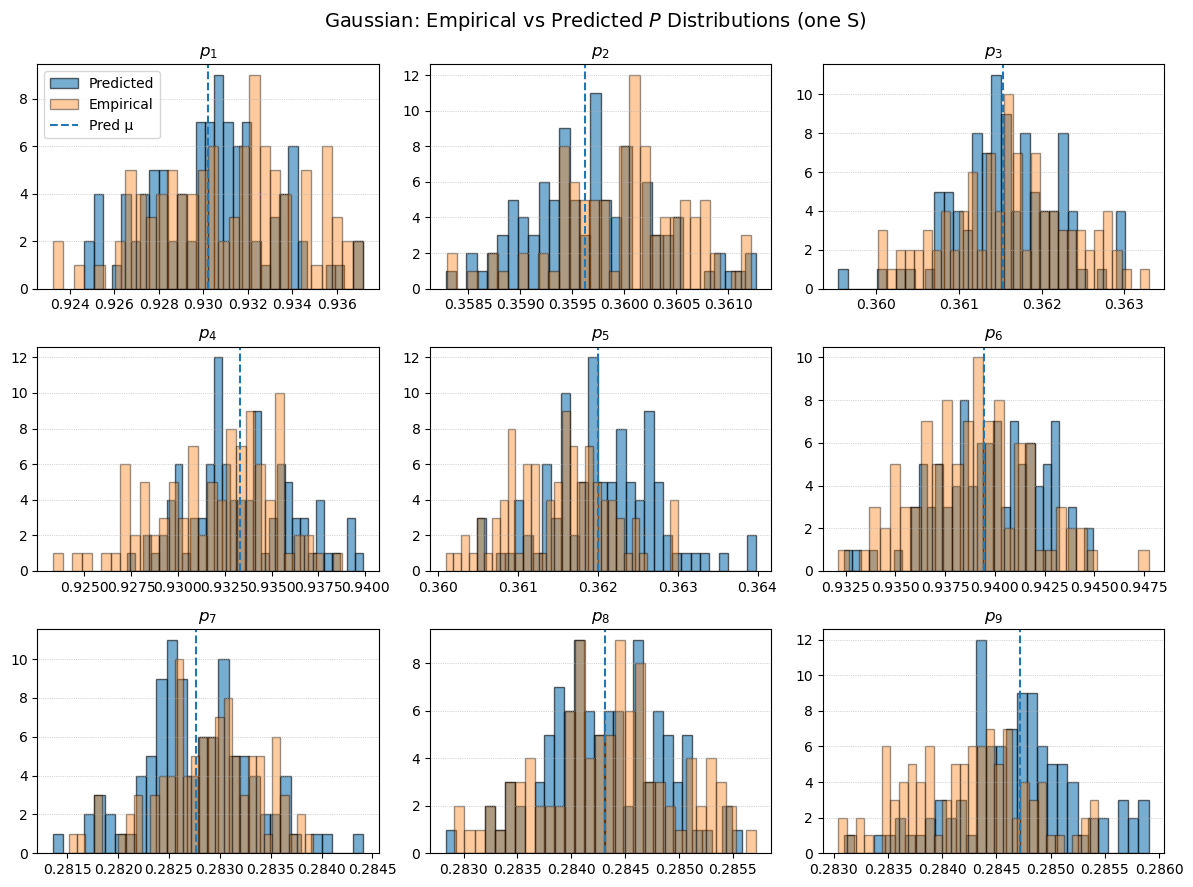

In [19]:
# === histogram comparison (pred vs empirical) ===
fig, axs = plt.subplots(3, 3, figsize=(12, 9))
axs = axs.flatten()

for i in range(P_DIM):
    axs[i].hist(P_hat_np[:, i], bins=30, alpha=0.6, edgecolor='black', label='Predicted')
    axs[i].hist(P_true_samples[:, i], bins=30, alpha=0.4, edgecolor='black', label='Empirical')
    axs[i].axvline(mu_hat_np[i], linestyle='--', label='Pred μ' if i==0 else None)
    axs[i].set_title(f"$p_{{{i+1}}}$")
    axs[i].grid(True, axis='y', linestyle=':', linewidth=0.5)
    if i == 0: axs[i].legend()

fig.suptitle("Gaussian: Empirical vs Predicted $P$ Distributions (one S)", fontsize=14)
plt.tight_layout()
plt.show()

### 7) Quick numeric summary table

In [20]:
# === numeric comparison: means, stds, coverage ===
print(f"{'comp':<6}{'μ_emp':>10}{'μ_pred':>10}{'σ_emp':>10}{'σ_pred':>10}{'Δμ':>10}{'σ*/σ':>10}{'cov68%':>10}{'cov95%':>10}")
print("-"*86)

sum_abs_dmu = sum_ratio = sum_cov68 = sum_cov95 = 0.0
row_fmt = "{comp:<6}{mu_emp:>10.4f}{mu_pred:>10.4f}{sigma_emp:>10.4f}{sigma_pred:>10.4f}{dmu:>10.4f}{ratio:>10.2f}{cov68:>10.2%}{cov95:>10.2%}"

for i in range(P_DIM):
    emp = P_true_samples[:, i]
    mu_emp, std_emp = emp.mean(), emp.std(ddof=0)
    mu_pred, std_pred = mu_hat_np[i], sigma_hat_np[i]

    cov68 = ((emp >= (mu_pred - std_pred)) & (emp <= (mu_pred + std_pred))).mean()
    cov95 = ((emp >= (mu_pred - 2*std_pred)) & (emp <= (mu_pred + 2*std_pred))).mean()

    dmu = mu_pred - mu_emp
    ratio = (std_pred / std_emp) if std_emp > 0 else float("nan")

    print(row_fmt.format(
        comp=i+1, mu_emp=mu_emp, mu_pred=mu_pred,
        sigma_emp=std_emp, sigma_pred=std_pred,
        dmu=dmu, ratio=ratio, cov68=cov68, cov95=cov95
    ))

    sum_abs_dmu += abs(dmu)
    sum_ratio   += ratio
    sum_cov68   += cov68
    sum_cov95   += cov95

n = P_DIM
empty10 = " " * 10
print("-"*86)
print(f"{'avg':<6}{empty10}{empty10}{empty10}{empty10}"
      f"{(sum_abs_dmu/n):>10.4f}{(sum_ratio/n):>10.2f}{(sum_cov68/n):>10.2%}{(sum_cov95/n):>10.2%}")


comp       μ_emp    μ_pred     σ_emp    σ_pred        Δμ      σ*/σ    cov68%    cov95%
--------------------------------------------------------------------------------------
1         0.9311    0.9302    0.0032    0.0031   -0.0009      0.95    60.00%    94.00%
2         0.3600    0.3596    0.0006    0.0007   -0.0004      1.12    65.00%    96.00%
3         0.3616    0.3615    0.0007    0.0007   -0.0001      0.90    60.00%    93.00%
4         0.9320    0.9333    0.0032    0.0028    0.0013      0.89    63.00%    88.00%
5         0.3615    0.3620    0.0006    0.0006    0.0005      1.02    58.00%    91.00%
6         0.9388    0.9394    0.0029    0.0028    0.0006      0.97    66.00%    95.00%
7         0.2829    0.2828    0.0005    0.0005   -0.0001      1.07    68.00%    97.00%
8         0.2843    0.2843    0.0006    0.0005   -0.0000      0.85    61.00%    89.00%
9         0.2842    0.2847    0.0006    0.0005    0.0005      0.95    49.00%    82.00%
-------------------------------------------

### 8) (Optional) Evaluate many S’s at once (MAE/MSE on μ only)

In [21]:
# === robust metrics over many S ===
import numpy as np, pandas as pd

num_to_eval = min(30, len(S_keys))
sel_indices = np.linspace(0, len(S_keys)-1, num_to_eval, dtype=int)

rows = []
all_z2 = []          # for global T
all_cov_triplets = []  # (emp, mu, sigma) tuples to recompute cov with T

LOG_2PI = np.log(2.0 * np.pi)

for sidx in sel_indices:
    S_arr = np.array(S_keys[sidx], float)
    emp   = empirical_data[S_keys[sidx]]
    n_emp = emp.shape[0]

    # predict μ, σ
    Sv = torch.tensor(S_arr, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        mu_n, log_sigma_n = model(norm_S(Sv))
    mu    = denorm_P(mu_n[0]).cpu().numpy()
    sigma = (torch.exp(log_sigma_n[0]) * P_std).cpu().numpy()

    # empirical stats
    mu_emp  = emp.mean(axis=0)
    std_emp = emp.std(axis=0, ddof=0)
    std_emp = np.where(std_emp < 1e-12, 1e-12, std_emp)

    # rho-aware scaling
    rho_val = float(S_arr[3])
    scale   = g_rho(rho_val)
    sigma   = np.clip(sigma * scale, a_min=EPS_SIG, a_max=None)

    # per-dim errors
    dmu          = mu - mu_emp
    mae_mu       = np.mean(np.abs(dmu))
    ratio_sigma  = np.mean(sigma / std_emp)

    # coverage across ALL samples & dims for this S
    lo1, hi1 = mu - sigma,     mu + sigma
    lo2, hi2 = mu - 2*sigma,   mu + 2*sigma
    cov68 = np.mean((emp >= lo1) & (emp <= hi1))
    cov95 = np.mean((emp >= lo2) & (emp <= hi2))

    # NLL (mean over samples & dims)
    z2  = ((emp - mu) / np.clip(sigma, 1e-12, None))**2
    nll = 0.5 * (z2 + 2.0*np.log(np.clip(sigma, 1e-12, None)) + LOG_2PI)
    nll = float(np.mean(nll))

    rows.append({
        "S_idx": int(sidx),
        "S": np.round(S_arr, 3).tolist(),   # full S vector
        "rho": float(S_arr[3]),             # just the volume ratio
        "MAE_mu": float(mae_mu),
        "ratio_sigma": float(ratio_sigma),
        "cov68": float(cov68),
        "cov95": float(cov95),
        "NLL": nll,
    })

    # accumulate for global T
    all_z2.append(z2)
    all_cov_triplets.append((emp.copy(), mu.copy(), sigma.copy()))


df = pd.DataFrame(rows).sort_values("S_idx").reset_index(drop=True)
all_z2 = np.concatenate(all_z2, axis=0)
T_global = float(np.sqrt(all_z2.mean()))

def cov_with_T(triplets, T):
    cnt = 0; total = 0
    for emp, mu, sigma in triplets:
        lo, hi = mu - T*sigma, mu + T*sigma
        inside = (emp >= lo) & (emp <= hi)
        cnt += inside.sum()
        total += inside.size
    return cnt / total

cov68_T = cov_with_T(all_cov_triplets, T_global)

# pretty print + save
display_cols = ["S_idx","S","rho","MAE_mu","ratio_sigma","cov68","cov95","NLL"]
print("\n========================== Per‑S summary (sorted by S_idx) ==========================")
print(df[display_cols].to_string(index=False, float_format=lambda x: f"{x:0.4f}"))

print("\n============ GLOBAL SUMMARY ============")
print(f"✅ Average over {len(sel_indices)} S: \n"
      f"    - MAE_mu = {df['MAE_mu'].mean():0.4f} \n"
      f"    - ratio_sigma = {df['ratio_sigma'].mean():0.2f} \n"
      f"    - cov68 = {df['cov68'].mean():0.2%} \n"
      f"    - cov95 = {df['cov95'].mean():0.2%} \n"
      f"    - NLL = {df['NLL'].mean():0.4f}")



========================== Per‑S summary (sorted by S_idx) ==========================
 S_idx                               S    rho  MAE_mu  ratio_sigma  cov68  cov95     NLL
     0       [21.811, 0.0, 0.0, 0.724] 0.7236  0.0005       0.7007 0.5267 0.8244 -4.2247
     1       [29.586, 0.0, 0.0, 0.481] 0.4814  0.0007       0.4852 0.3489 0.6322 -3.5572
     2  [32.806, 24.674, 20.197, 0.65] 0.6501  0.0018       0.7398 0.4811 0.8167 -3.8020
     3    [32.898, 20.496, 0.0, 0.319] 0.3186  0.0005       0.3895 0.2600 0.4922 -1.9368
     4       [35.438, 0.0, 0.0, 0.612] 0.6115  0.0007       0.6364 0.4589 0.7722 -4.2976
     5    [39.383, 34.081, 0.0, 0.644] 0.6440  0.0009       0.6901 0.4889 0.8056 -4.1261
     6       [42.761, 0.0, 0.0, 0.513] 0.5135  0.0003       0.5425 0.4267 0.7211 -4.1757
     7       [47.999, 0.0, 0.0, 0.978] 0.9782  0.0004       2.1307 0.6667 0.9744 -6.2677
     8     [49.351, 33.519, 0.0, 0.48] 0.4797  0.0003       0.5069 0.3833 0.6767 -3.9954
     9        [53.893, 